loss: 3910.7444595849356


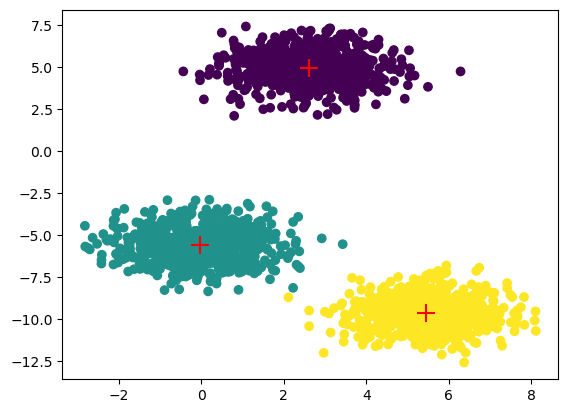

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
from sklearn.datasets import make_blobs

class KMeans_Plus_Plus:
    def __init__(self,k,max_iter = 10):
        """
        K-means聚类算法
        参数:
        k: 聚类簇数
        max_iter: 最大迭代次数
        """
        self.k = k
        self.max_iter = max_iter
        self.centroids  = None # 聚类中心
        self.labels = None # 聚类标签

    def calculate_distance(self,x,μ):
        """计算样本点与聚类中心之间的欧氏距离"""
        return np.sqrt(np.sum((x - μ)**2))
    
    def find_closest_centroid(self,distances):
        """返回最近的聚类中心索引"""
        return np.argmin(distances)
    
    def fit(self,data):
        """训练"""
        self.labels = np.zeros(len(data))
        # 初始化聚类中心
        # 随机选一个样本点作为第一个聚类中心
        centers = [data[np.random.randint(len(data))]]
        # 迭代选择k-1个聚类中心
        for _ in range(1,self.k):
            # 计算每一个样本到最近的聚类中心的距离平方
            distances = []
            for i in range(len(data)):
                d = np.inf
                for j in range(len(centers)):
                    d_ij = self.calculate_distance(data[i],centers[j])
                    if d_ij < d:
                        d = d_ij
                distances.append(d**2)
            # 计算每个样本点的权重
            probs = np.array(distances) / np.sum(distances)
            # 根据轮盘赌选择下一个聚类中心
            cum_probs = np.cumsum(probs)
            r = np.random.rand()
            for j in range(len(cum_probs)):
                if r < cum_probs[j]:
                    centers.append(data[j])
                    break
        self.centroids = np.array(centers)

        # 迭代寻找最优解 
        for i in range(self.max_iter):
            # E-step
            for j in range(len(data)):
                distances = []
                for k in range(self.k):
                    d = self.calculate_distance(data[j],self.centroids[k])
                    distances.append(d)
                # 找到最近的聚类中心
                closest_centroid = self.find_closest_centroid(distances)
                # 更新样本点的标签
                self.labels[j] = closest_centroid
            # M-step
            for j in range(self.k):
                # 更新聚类中心
                new_centroids = np.mean(data[self.labels == j],axis = 0)
                self.centroids[j] = new_centroids

    def Loss(self):
        """计算损失 公式(9.24)"""
        Loss = 0
        for i in range(self.k):
            points = data[self.labels == i]
            Loss += np.sum((points - self.centroids[i])**2)
        return Loss
    
if __name__ == '__main__':
    # 加载数据
    data = make_blobs(n_samples = 2000,n_features = 2,centers = 3,random_state = 10)[0]
    # 实例化KMeans
    kmeans = KMeans_Plus_Plus(k = 3,max_iter = 5)
    # 训练
    kmeans.fit(data)
    loss = kmeans.Loss()
    print("loss:",loss)
    # 可视化
    plt.scatter(data[:,0],data[:,1],c = kmeans.labels)
    plt.scatter(kmeans.centroids[:,0],kmeans.centroids[:,1],marker = '+',s = 150,c = 'r')
    plt.show()